# Orders EDA - Focused Analytics

Descriptive EDA, data cleaning, trends, segmentation, and bottleneck analysis.

In [17]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Load and normalize source tables

In [18]:
csv_files = sorted(Path('.').glob('*.csv'))
if not csv_files: raise FileNotFoundError('No CSV files found.')
tables = {p.stem.lower(): pd.read_csv(p) for p in csv_files}
orders = next((v for k, v in tables.items() if 'order' in k), next(iter(tables.values())))
returns = next((v for k, v in tables.items() if 'return' in k), None)
people = next((v for k, v in tables.items() if 'people' in k or 'person' in k), None)
for table in [orders, returns, people]:
    if table is not None:
        for column in ['Order Date', 'Ship Date', 'Return Date']:
            if column in table: table[column] = pd.to_datetime(table[column], dayfirst=True, errors='coerce')
print('Available tables:', ', '.join(sorted(tables)))
print(f'Orders shape: {orders.shape} | Returns: {returns is not None} | People: {people is not None}')
display(orders.head())

Available tables: orders
Orders shape: (10194, 23) | Returns: False | People: False


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,TotalPrice,TotalCost
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55,10.70,8.56
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49,4.11,3.29
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27,2.44,1.95
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77,112.44,89.95
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88,4.82,3.85


## 2. Descriptive EDA

### Nulls, blanks, summary statistics, and outlier detection

In [19]:
def null_profile(table, name):
    return pd.DataFrame({'table': name, 'dtype': table.dtypes.astype(str), 'nulls': table.isna().sum(), 'blanks': table.apply(lambda c: c.astype('string').str.strip().eq('').sum()), 'missing_pct': (table.isna().mean() * 100).round(2), 'unique': table.nunique()}).reset_index(names='column')
profiles = [null_profile(orders, 'Orders')]
if returns is not None: profiles.append(null_profile(returns, 'Returns'))
if people is not None: profiles.append(null_profile(people, 'People'))
nulls_blanks = pd.concat(profiles, ignore_index=True)
display(nulls_blanks.sort_values(['table', 'nulls', 'blanks'], ascending=False))
numeric = orders.select_dtypes(include=np.number).columns
stats = orders[numeric].agg(['count', 'mean', 'median', 'min', 'max', 'std']).T.rename(columns={'std': 'stddev'})
display(stats)
outliers = []
for column in numeric:
    values = orders[column].dropna(); q1, q3 = values.quantile([.25, .75]); iqr = q3 - q1
    z = ((orders[column] - values.mean()) / values.std(ddof=0)).abs() if values.std(ddof=0) else 0
    iqr_mask = (orders[column] < q1 - 1.5 * iqr) | (orders[column] > q3 + 1.5 * iqr)
    outliers.append({'column': column, 'q1': q1, 'q3': q3, 'iqr_outliers': int(iqr_mask.sum()), 'zscore_outliers': int((z > 3).sum()), 'combined_outliers': int((iqr_mask | (z > 3)).sum())})
outlier_summary = pd.DataFrame(outliers).sort_values('combined_outliers', ascending=False)
display(outlier_summary)

,column,table,dtype,nulls,blanks,missing_pct,unique
0,Row ID,Orders,int64,0,0,0.00,10194
1,Order ID,Orders,str,0,0,0.00,5111
2,Order Date,Orders,datetime64[us],0,0,0.00,1242
3,Ship Date,Orders,datetime64[us],0,0,0.00,1338
4,Ship Mode,Orders,str,0,0,0.00,4
5,Customer ID,Orders,str,0,0,0.00,804
6,Customer Name,Orders,str,0,0,0.00,800
7,Segment,Orders,str,0,0,0.00,3
8,Country/Region,Orders,str,0,0,0.00,2
9,City,Orders,str,0,0,0.00,542


,count,mean,median,min,max,stddev
Row ID,"10,194.00","5,097.50","5,097.50",1.00,"10,194.00","2,942.90"
Sales,"10,194.00",228.23,53.91,0.44,"22,638.48",619.91
Quantity,"10,194.00",3.79,3.00,1.00,14.00,2.23
Discount,"10,194.00",0.16,0.20,0.00,0.80,0.21
Profit,"10,194.00",28.67,8.69,"-6,599.98","8,399.98",232.47
TotalPrice,"10,194.00",52.78,12.59,0.45,"4,074.84",121.75
TotalCost,"10,194.00",42.23,10.07,0.36,"3,259.87",97.40


,column,q1,q3,iqr_outliers,zscore_outliers,combined_outliers
4,Profit,1.76,29.30,1913,109,1913
1,Sales,17.22,209.50,1183,128,1183
5,TotalPrice,3.43,54.48,1176,117,1176
6,TotalCost,2.74,43.59,1176,117,1176
3,Discount,0.00,0.20,874,301,874
2,Quantity,2.00,5.00,175,114,175
0,Row ID,"2,549.25","7,645.75",0,0,0


## 3. Data Cleaning

Client validation reports missing keys; internal imputation is applied only to a separate analysis copy. Orders, Returns, and People remain normalized as separate tables.

In [20]:
raw_orders = orders.copy()
clean_orders = orders.copy()
required = [c for c in ['Order ID', 'Order Date', 'Customer ID', 'Product ID'] if c in clean_orders]
client_validation = pd.DataFrame({'field': required, 'invalid_or_missing_rows': [int(clean_orders[c].isna().sum() + clean_orders[c].astype('string').str.strip().eq('').sum()) for c in required]})
print('Client validation (source issues):'); display(client_validation)
for column in clean_orders.select_dtypes(include=np.number):
    if column != 'Row ID': clean_orders[column] = clean_orders[column].fillna(clean_orders[column].median())
for column in clean_orders.select_dtypes(include='object'):
    if column not in required: clean_orders[column] = clean_orders[column].replace(r'^\s*$', np.nan, regex=True).fillna('Unknown')
duplicates = int(clean_orders.duplicated().sum())
clean_orders = clean_orders.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {duplicates:,} | Clean rows: {len(clean_orders):,}')
expected = {'Orders': {'Order ID', 'Order Date', 'Customer ID', 'Product ID', 'Sales', 'Quantity', 'Profit'}, 'Returns': {'Order ID'}, 'People': {'Person'}}
schema_rows = []
for name, table in [('Orders', raw_orders), ('Returns', returns), ('People', people)]:
    missing = sorted(expected[name] - set(table.columns)) if table is not None else []
    schema_rows.append({'table': name, 'status': 'Not available' if table is None else ('Valid' if not missing else 'Review'), 'missing_expected_columns': ', '.join(missing) if missing else 'None', 'duplicate_rows': 'n/a' if table is None else int(table.duplicated().sum())})
display(pd.DataFrame(schema_rows))

Client validation (source issues):


,field,invalid_or_missing_rows
0,Order ID,0
1,Order Date,0
2,Customer ID,0
3,Product ID,0


Duplicates removed: 0 | Clean rows: 10,194


,table,status,missing_expected_columns,duplicate_rows
0,Orders,Valid,None,0
1,Returns,Not available,None,n/a
2,People,Not available,None,n/a


## 4. Exploratory Extensions

### Trends - sales, profit, and returns

,Month,Orders,Sales,Profit
0,2023-01,33,"14,518.06","2,539.39"
1,2023-02,28,"4,519.89",862.31
2,2023-03,72,"56,933.91",693.45
3,2023-04,66,"28,295.35","3,488.84"
4,2023-05,72,"26,319.77","3,196.39"
5,2023-06,67,"34,669.48","4,999.76"
6,2023-07,65,"33,946.39",-841.48
7,2023-08,75,"28,918.34","5,765.23"
8,2023-09,134,"82,670.43","8,593.63"
9,2023-10,81,"32,413.34","3,469.17"


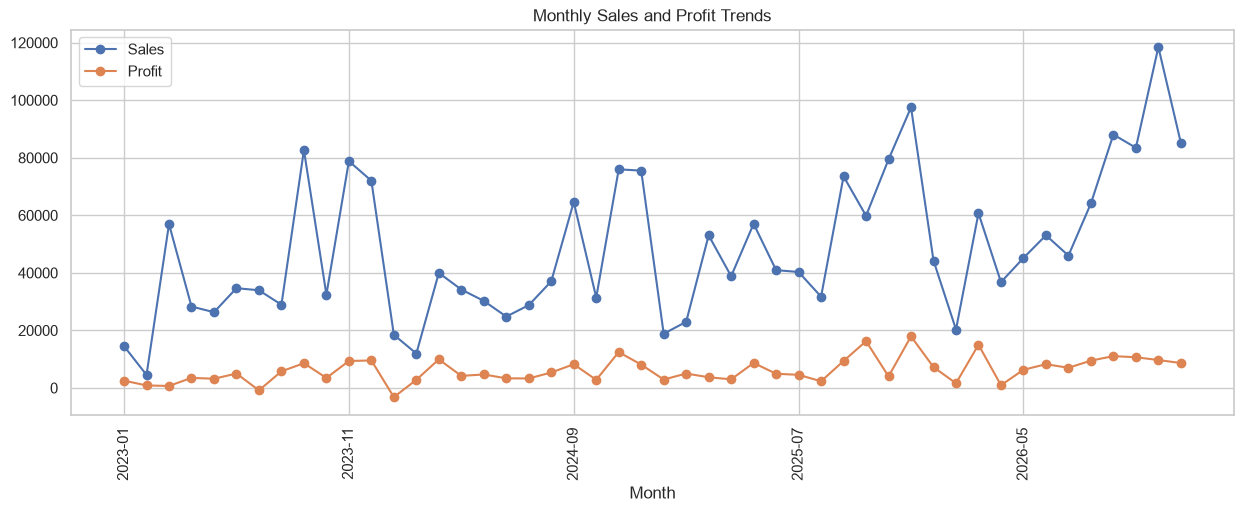

Return trend unavailable: Returns table with Order ID not found.


In [22]:
trend = clean_orders.dropna(subset=['Order Date']).copy() if 'Order Date' in clean_orders else pd.DataFrame()
if not trend.empty:
    trend['Month'] = trend['Order Date'].dt.to_period('M').astype(str)
    monthly = trend.groupby('Month').agg(Orders=('Order ID', 'nunique'), Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
    display(monthly)
    monthly.plot(x='Month', y=['Sales', 'Profit'], marker='o', figsize=(15, 5), title='Monthly Sales and Profit Trends'); plt.xticks(rotation=90); plt.show()
    if returns is not None and 'Order ID' in returns and 'Order ID' in trend:
        return_trend = returns.merge(trend[['Order ID', 'Month']].drop_duplicates(), on='Order ID', how='left').groupby('Month').size().reset_index(name='Returns')
        display(return_trend)
        return_trend.plot(x='Month', y='Returns', marker='o', figsize=(15, 4), title='Monthly Return Trend'); plt.xticks(rotation=90); plt.show()
    else: print('Return trend unavailable: Returns table with Order ID not found.')
else: print('Sales/profit trend unavailable: Order Date not found.')

### Segmentation - customers, regions, and product categories

In [21]:
def segment_summary(column):
    aggregations = {'Rows': (column, 'size'), 'Orders': ('Order ID', 'nunique'), 'Sales': ('Sales', 'sum'), 'Profit': ('Profit', 'sum')}
    result = clean_orders.groupby(column).agg(**aggregations).sort_values('Sales', ascending=False)
    result['Profit Margin %'] = result['Profit'] / result['Sales'].replace(0, np.nan) * 100
    return result
for dimension in ['Segment', 'Region', 'Category', 'Sub-Category']:
    if dimension in clean_orders: print(f'### {dimension}'); display(segment_summary(dimension))

### Segment


,Rows,Orders,Sales,Profit,Profit Margin %
Segment,,,,,
Consumer,5281,2628,"1,170,659.79","136,371.45",11.65
Corporate,3090,1552,"715,806.13","94,249.64",13.17
Home Office,1823,931,"440,068.43","61,675.73",14.02


### Region


,Rows,Orders,Sales,Profit,Profit Margin %
Region,,,,,
West,3253,1635,"739,813.61","110,798.82",14.98
East,2986,1475,"691,828.17","94,883.26",13.71
Central,2335,1179,"503,170.67","39,865.31",7.92
South,1620,822,"391,721.90","46,749.43",11.93


### Category


,Rows,Orders,Sales,Profit,Profit Margin %
Category,,,,,
Technology,1865,1560,"839,893.28","146,543.38",17.45
Furniture,2201,1819,"754,747.76","19,730.00",2.61
Office Supplies,6128,3812,"731,893.31","126,023.44",17.22


### Sub-Category


,Rows,Orders,Sales,Profit,Profit Margin %
Sub-Category,,,,,
Chairs,634,591,"335,768.25","27,223.53",8.11
Phones,903,826,"331,842.64","45,050.83",13.58
Storage,856,787,"224,644.55","21,285.11",9.48
Tables,326,314,"208,020.18","-17,753.21",-8.53
Binders,1548,1339,"207,354.88","31,426.10",15.16
Machines,117,114,"189,925.03","3,461.98",1.82
Accessories,775,718,"167,380.32","41,936.64",25.05
Copiers,70,70,"150,745.29","56,093.94",37.21
Bookcases,232,228,"115,361.20","-3,632.07",-3.15


### Bottlenecks - shipping, returns, and data

In [23]:
if {'Order Date', 'Ship Date'}.issubset(clean_orders.columns):
    shipping = clean_orders.dropna(subset=['Order Date', 'Ship Date']).copy()
    shipping['Shipping Days'] = (shipping['Ship Date'] - shipping['Order Date']).dt.days
    display(shipping['Shipping Days'].describe().to_frame().T)
    if 'Ship Mode' in shipping: display(shipping.groupby('Ship Mode')['Shipping Days'].agg(['count', 'mean', 'median', 'max']).sort_values('mean', ascending=False))
    print(f'Orders shipped in more than 7 days: {(shipping["Shipping Days"] > 7).sum():,}')
else: print('Shipping bottleneck unavailable.')
if returns is not None and 'Order ID' in returns:
    return_counts = returns['Order ID'].value_counts(); print(f'Returned orders: {return_counts.size:,} | Return records: {len(returns):,}'); display(return_counts.describe().to_frame().T)
else: print('Return bottleneck unavailable.')
print('Data bottlenecks requiring source remediation:')
display(nulls_blanks.query('nulls > 0 or blanks > 0').sort_values(['nulls', 'blanks'], ascending=False).head(20))

,count,mean,std,min,25%,50%,75%,max
Shipping Days,"10,194.00",3.96,1.74,0.00,3.00,4.00,5.00,11.00


,count,mean,median,max
Ship Mode,,,,
Standard Class,6120,5.00,5.00,11
Second Class,1979,3.24,3.00,5
First Class,1548,2.18,2.00,4
Same Day,547,0.04,0.00,1


Orders shipped in more than 7 days: 2
Return bottleneck unavailable.
Data bottlenecks requiring source remediation:


,column,table,dtype,nulls,blanks,missing_pct,unique
